<a href="https://colab.research.google.com/github/k-sahaj/Data-Science-Learnings/blob/main/ML/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Understanding Logistic Regression using Perceptron trick**

In [12]:
from sklearn.datasets import make_classification

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

## Perceptron trick vs Logistic Regression

In [2]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

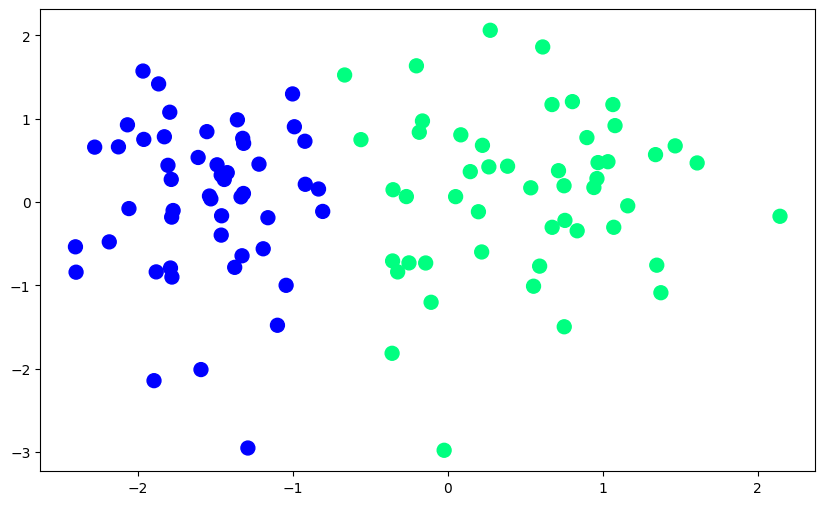

In [3]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [4]:
def perceptron(X,y):

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]

    return weights[0],weights[1:]

def step(z):
    return 1 if z>0 else 0

In [5]:
intercept_,coef_ = perceptron(X,y)

print(coef_)
print(intercept_)

[1.36463668 0.19242098]
0.9


In [7]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

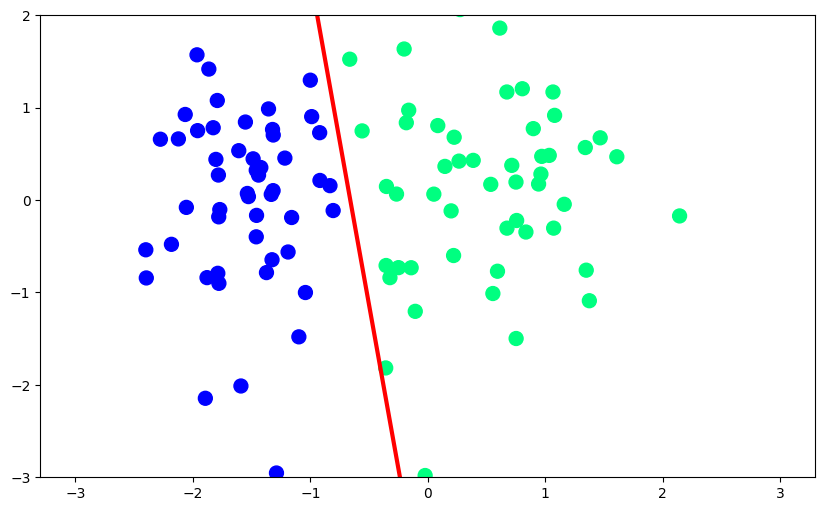

In [8]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [9]:
#to show visually what and how everything is going on:

def perceptron(X,y):

    m = []
    b = []

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]

        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))

    return m,b

In [10]:
m,b = perceptron(X,y)

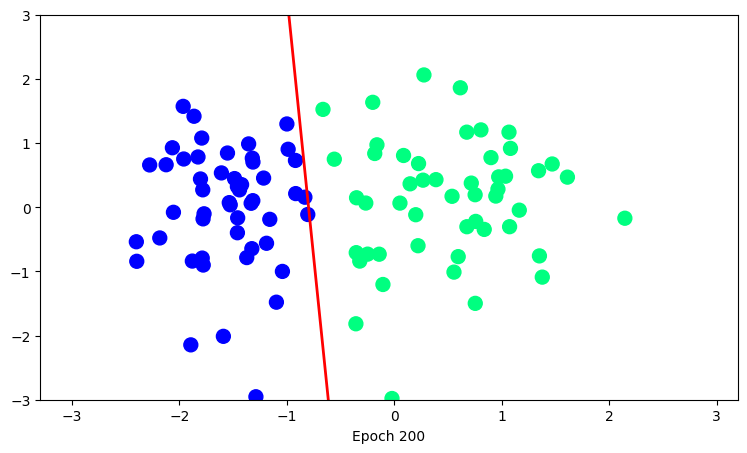

In [14]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
ax.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
line, = ax.plot(x_i, x_i*m[0] + b[0], 'r-', linewidth=2)
ax.set_ylim(-3, 3)

def update(i):
    line.set_ydata(x_i * m[i] + b[i])
    ax.set_xlabel(f"Epoch {i+1}")
    return line,

anim = FuncAnimation(fig, update, frames=len(m), interval=100, blit=True)

HTML(anim.to_html5_video())

In [15]:
lor = LogisticRegression()
lor.fit(X,y)

LogisticRegression()

In [16]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

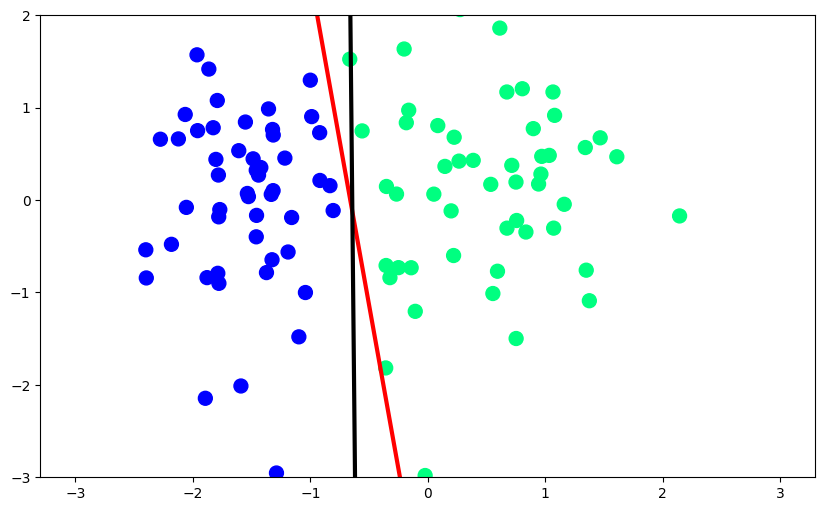

In [17]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

plt.show()

Here the logistic regression wala line and perceptron trick wala line both are almost same. Did we crack it? No. Abhi bhi bohot issues hain isme. The line is still random in perceptron trick. Let's understand with the next example

## Fixing the randomness flaw with Sigmoid function

In [18]:
#Let's take another dataset example to actually see how much wrong our model is rn:

X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=30)

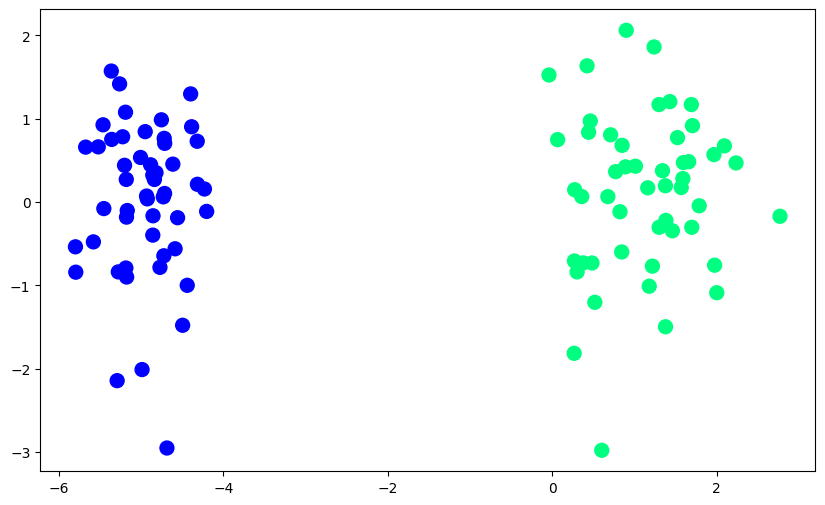

In [19]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [20]:
def perceptron(X,y):

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]

    return weights[0],weights[1:]

def step(z):
    return 1 if z>0 else 0

In [21]:
intercept_,coef_ = perceptron(X,y)

print(coef_)
print(intercept_)

[1.1204053  0.40381514]
1.2000000000000002


In [22]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

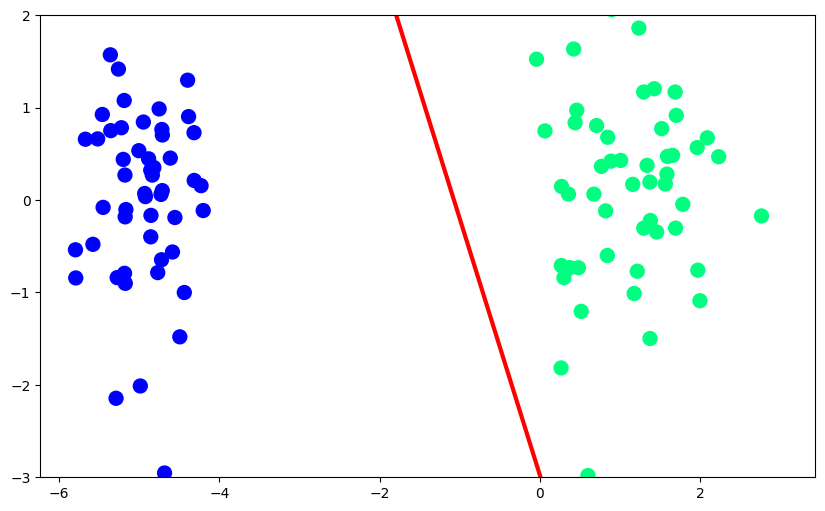

In [23]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [24]:
lor = LogisticRegression()
lor.fit(X,y)

m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

(-3.0, 2.0)

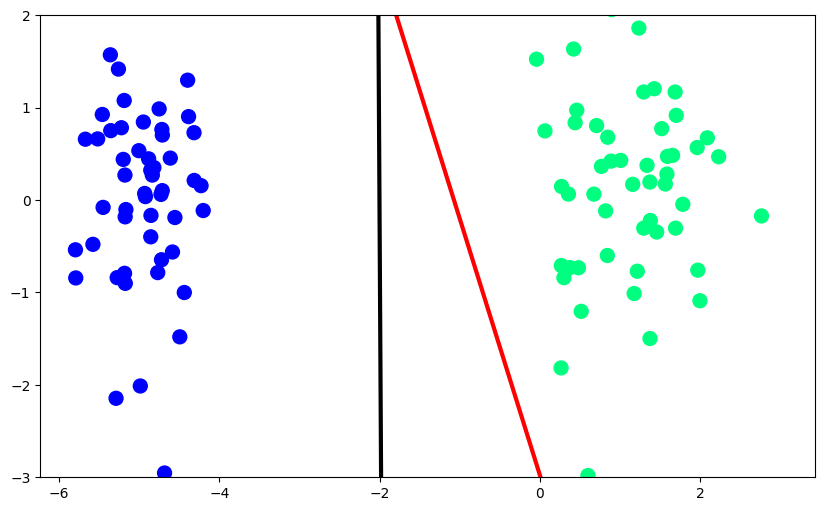

In [25]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

What can be the solution now? - Using Sigmoid function instead.

It will act as a probability distribution and the line will play push-pull game more effectively. Instead of focusing just on misclassified points, we'll consider all the points and their types where all of them play some roles in changing the line. Some more, some less, some positively, some negatively.

In [26]:
def perceptron(X,y):

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = sigmoid(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]

    return weights[0],weights[1:]

def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [27]:
intercept_,coef_ = perceptron(X,y)

m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

x_input2 = np.linspace(-3,3,100)
y_input2 = m*x_input2 + b

(-3.0, 2.0)

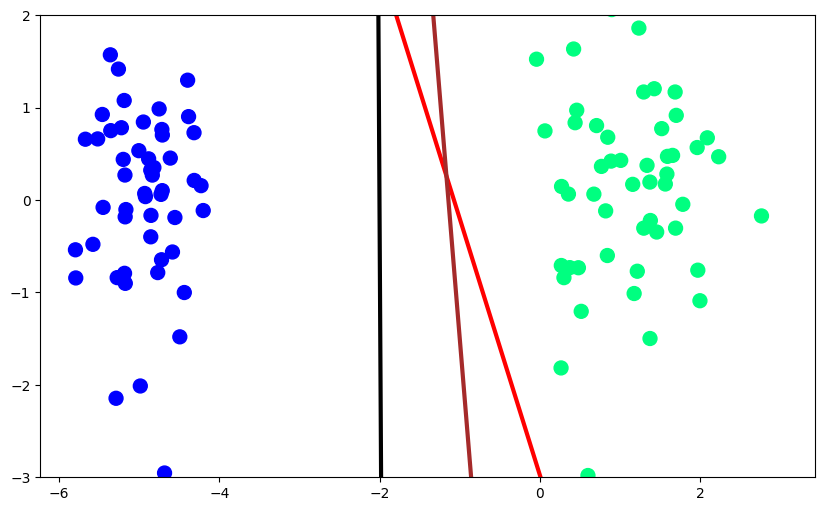

In [28]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.plot(x_input2,y_input2,color='brown',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

Now did we crack it? - Almost but still no.

There's still some flaw in sigmoid perceptron approach. The possible solution is to use some legit loss function to have an understanding and measure of the wrongness.

MAXIMUM LIKELIHOOD. we'll integrate log-loss error (Binary cross entropy) but it has no closed-form solution. So we'll use gradient descent too to find weights with minimum error and that will be our line. (see notes)


In [51]:
# lor = LogisticRegression(penalty=None,solver='sag')
# lor.fit(X,y)

# print(lor.coef_)
# print(lor.intercept_)

# m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
# b1 = -(lor.intercept_/lor.coef_[0][1])

# x_input = np.linspace(-3,3,100)
# y_input = m1*x_input + b1

In [29]:
def gd(X,y):

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.5

    for i in range(5000):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + lr*(np.dot((y-y_hat),X)/X.shape[0])

    return weights[1:],weights[0]

def sigmoid(z):
    return 1/(1 + np.exp(-z))


In [30]:
coef_,intercept_ = gd(X,y)

m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

x_input3 = np.linspace(-3,3,100)
y_input3 = m*x_input3 + b

(-3.0, 2.0)

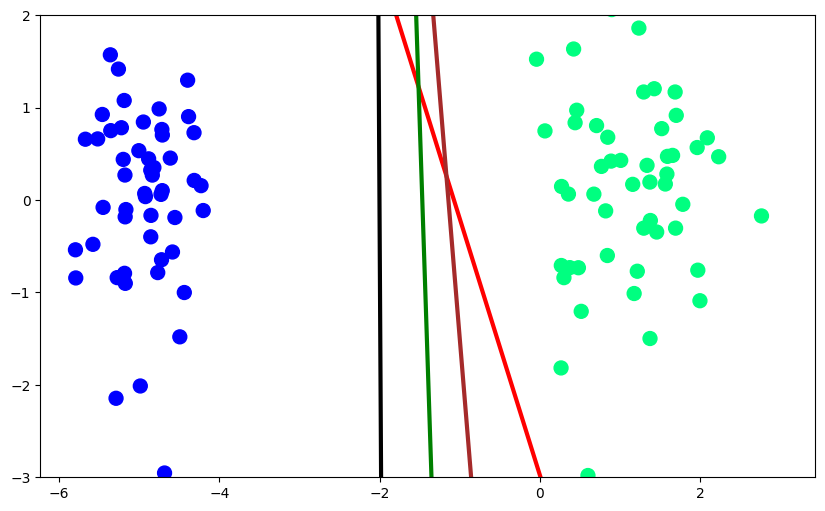

In [41]:

plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.plot(x_input2,y_input2,color='brown',linewidth=3)
plt.plot(x_input3,y_input3,color='green',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

Here,

Black - Logistic Regression (with penalty on)   
Red - Perceptron trick with step funtion   
Brown - Perceptron trick with sigmoid function    
Green - With loss function   

Now as we can see, the green and black lines are almost similar now. It shows ki apna code sahi hai for achieving Logistic regression jitna accuracy.   
The only stopping is that the penalty wala factor. If we turn that off, let's see.


In [44]:
lor = LogisticRegression(penalty=None)
lor.fit(X,y)

print(lor.coef_)
print(lor.intercept_)

m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])

x_input4 = np.linspace(-3,3,100)
y_input4 = m1*x_input4 + b1

[[4.2408842  0.18227295]]
[6.57993897]


(-3.0, 2.0)

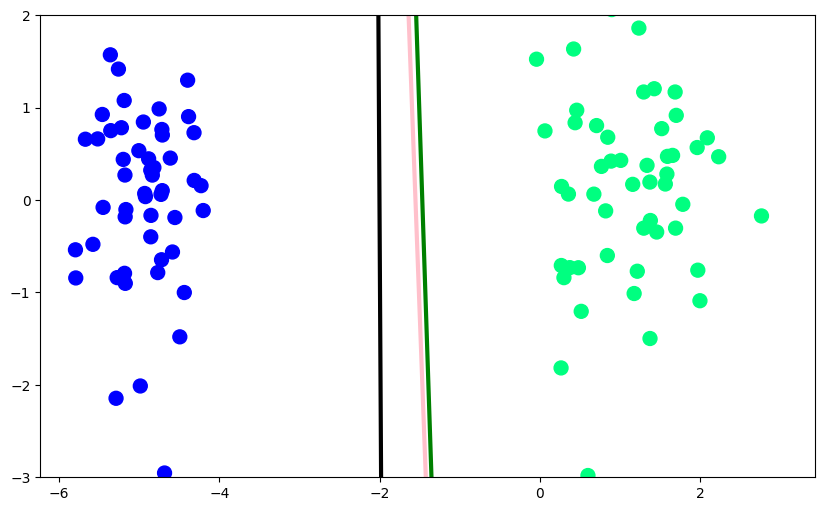

In [45]:

plt.figure(figsize=(10,6))
plt.plot(x_input1,y_input1,color='black',linewidth=3)

plt.plot(x_input3,y_input3,color='green',linewidth=3)
plt.plot(x_input4,y_input4,color='pink',linewidth=3)

plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

There it is! The pink line is the logistic regression without penalty and it is almost exactly same as our manual made up line with perceptron trick along with sigmoid function using Log loss error as its loss function and gradient descent.

It shows ki actual me logistic regression kaise code kiya gaya hoga. What actually is the intuition behind it. What is happening Behind the Scenes.

Therefore, we conclude Logistic Regression.